### Zomato Restaurant Analysis

### Data Dictionary
RestaurantID: A unique numerical identifier for each restaurant (Primary Key).

RestaurantName: The official name of the eating establishment.

CountryCode: A numerical code representing the country (Foreign Key to link with the Country Lookup table).

City: The city where the restaurant is located.

Address: The complete physical address of the restaurant.

Locality: The specific neighborhood or district within the city.

LocalityVerbose: An extended description of the locality (often combining City and Locality names).

Longitude: The geographic coordinate specifying the east-west position (used for mapping).

Latitude: The geographic coordinate specifying the north-south position (used for mapping).

Cuisines: A list of food styles or categories served (e.g., Italian, Chinese, Fast Food).

Currency: The local currency used for transactions in that specific country.

Has_Table_booking: A binary field (Yes/No) indicating if customers can reserve a table in advance.

Has_Online_delivery: A binary field (Yes/No) indicating if the restaurant offers home delivery through the platform.

Is_delivering_now: Indicates if the restaurant is currently accepting and delivering orders at this moment.

Switch_to_order_menu: A technical flag (usually static in this dataset) suggesting a UI/UX feature for ordering.

Average_Cost_for_two: The approximate cost for two people to have a meal (in the local currency).

Price_range: A categorical classification of cost (1 = Inexpensive, 2 = Mid-range, 3 = Expensive, 4 = Luxury).

Aggregate_rating: The weighted average rating of the restaurant based on user reviews (scaled 0 to 5).

Rating_color: A color code representing the rating tier (e.g., Dark Green for Excellent, Orange for Average).

Rating_text: The qualitative description of the rating (e.g., "Excellent", "Very Good", "Poor").

Votes: The total count of individual customer reviews/ratings submitted.

Datekey_Opening: The specific date the restaurant was registered or opened on the platform.

Year / Month / Quarter: (Derived Columns) Extracted from Datekey_Opening to perform Time-Series analysis.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

C:\Users\hp\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\hp\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# contains Zomato Restaurant
df1=pd.read_excel(r"D:\Imarticus pg Diploma\Capstone- Zomato Restaurants Analysis\zomato_data.xlsx")

In [3]:
# contains Country name using countrycode
df2=pd.read_excel(r"D:\Imarticus pg Diploma\Capstone- Zomato Restaurants Analysis\zomato_data.xlsx",sheet_name="Sheet2")

In [4]:
df2.head()

,countryID,country name
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia


In [5]:
df=pd.merge(left=df1,right=df2,left_on="CountryCode",right_on="countryID",how="inner")

### Exploratory Data Analysis 

In [6]:
df.head()

,RestaurantID,RestaurantName,CountryCode,City,Address,Locality,LocalityVerbose,Longitude,Latitude,Cuisines,...,Cuisines 1,Cuisines 2,Cuisines 3,Cuisines 4,Cuisines 5,Cuisines 6,Cuisines 7,Cuisines 8,countryID,country name
0,18435314,Punjabi's Veg Grill,1,New Delhi,"13/288 , 14 Block Gurudwra, Geeta Colony, New ...",Geeta Colony,"Geeta Colony, New Delhi",77.276769,28.650775,North Indian,...,North Indian,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,India
1,18378015,Tasty Tandoor,1,New Delhi,"726/2, Jheel Khuranja, Geeta Colony, New Delhi",Geeta Colony,"Geeta Colony, New Delhi",77.275052,28.658216,North Indian,...,North Indian,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,India
2,18424905,Taste of Spice,1,New Delhi,"C-222, Lajpat Nagar 1, New Delhi",Lajpat Nagar 1,"Lajpat Nagar 1, New Delhi",77.241312,28.578311,North Indian,...,North Indian,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,India
3,18180072,Kolcata Bengali Dhaba,1,New Delhi,"Gali 7, Mahipalpur, New Delhi",Mahipalpur,"Mahipalpur, New Delhi",77.123932,28.543587,North Indian,...,North Indian,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,India
4,18415377,Sunil Punjabi Dhaba,1,New Delhi,"Main Vasant Kunj Road, Mahipalpur, New Delhi",Mahipalpur,"Mahipalpur, New Delhi",77.129706,28.541369,North Indian,...,North Indian,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,India


In [7]:
df.shape

(9551, 31)

In [8]:
df.isnull().sum()

RestaurantID               0
RestaurantName             0
CountryCode                0
City                       0
Address                    0
Locality                   0
LocalityVerbose            0
Longitude                  0
Latitude                   0
Cuisines                   9
Currency                   0
Has_Table_booking          0
Has_Online_delivery        0
Is_delivering_now          0
Switch_to_order_menu       0
Price_range                0
Votes                      0
Average_Cost_for_two       0
Rating                     0
Datekey_Opening            0
Unnamed: 20             9551
Cuisines 1                 9
Cuisines 2              3403
Cuisines 3              6847
Cuisines 4              8687
Cuisines 5              9271
Cuisines 6              9435
Cuisines 7              9509
Cuisines 8              9537
countryID                  0
country name               0
dtype: int64

In [9]:
# As unnamed:20 has 9551 null so dropping this and countrycode , country id are basically for merging two tables 
df=df.drop(["Unnamed: 20","CountryCode","countryID"],axis=1)

In [10]:
df.columns

Index(['RestaurantID', 'RestaurantName', 'City', 'Address', 'Locality',
       'LocalityVerbose', 'Longitude', 'Latitude', 'Cuisines', 'Currency',
       'Has_Table_booking', 'Has_Online_delivery', 'Is_delivering_now',
       'Switch_to_order_menu', 'Price_range', 'Votes', 'Average_Cost_for_two',
       'Rating', 'Datekey_Opening', 'Cuisines 1', 'Cuisines 2', 'Cuisines 3',
       'Cuisines 4', 'Cuisines 5', 'Cuisines 6', 'Cuisines 7', 'Cuisines 8',
       'country name'],
      dtype='str')

In [11]:
# "Cuisines 1","Cuisines 2","Cuisines 3","Cuisines 4","Cuisines 5","Cuisines 6","Cuisines 7","Cuisines 8" replacing name
df.columns.str.replace(" ","_",regex=False)

Index(['RestaurantID', 'RestaurantName', 'City', 'Address', 'Locality',
       'LocalityVerbose', 'Longitude', 'Latitude', 'Cuisines', 'Currency',
       'Has_Table_booking', 'Has_Online_delivery', 'Is_delivering_now',
       'Switch_to_order_menu', 'Price_range', 'Votes', 'Average_Cost_for_two',
       'Rating', 'Datekey_Opening', 'Cuisines_1', 'Cuisines_2', 'Cuisines_3',
       'Cuisines_4', 'Cuisines_5', 'Cuisines_6', 'Cuisines_7', 'Cuisines_8',
       'country_name'],
      dtype='str')

In [12]:
df.columns=['RestaurantID', 'RestaurantName', 'City', 'Address',
       'Locality', 'LocalityVerbose', 'Longitude', 'Latitude', 'Cuisines',
       'Currency', 'Has_Table_booking', 'Has_Online_delivery',
       'Is_delivering_now', 'Switch_to_order_menu', 'Price_range', 'Votes',
       'Average_Cost_for_two', 'Rating', 'Datekey_Opening', 'Cuisines_1',
       'Cuisines_2', 'Cuisines_3', 'Cuisines_4', 'Cuisines_5', 'Cuisines_6',
       'Cuisines_7', 'Cuisines_8','country_name']

In [13]:
df["Datekey_Opening"].head(5)

0    2013_9_21
1    2016_9_10
2    2018_9_25
3     2018_9_6
4    2013_9_17
Name: Datekey_Opening, dtype: str

In [14]:
# making datekey col to datetime 
df["Datekey_Opening"]=pd.to_datetime(df["Datekey_Opening"],format='%Y_%m_%d',errors="coerce")

In [15]:
# Feature Engineering make year, month , month_name, quarter 
df["opening_year"]=df["Datekey_Opening"].dt.year
df["opening_month"]=df["Datekey_Opening"].dt.month
df["opening_monthname"]=df["Datekey_Opening"].dt.month_name()  # for Power BI
df["opening_quarter"]=df["Datekey_Opening"].dt.quarter

In [16]:
df.head().T

,0,1,2,3,4
RestaurantID,18435314,18378015,18424905,18180072,18415377
RestaurantName,Punjabi's Veg Grill,Tasty Tandoor,Taste of Spice,Kolcata Bengali Dhaba,Sunil Punjabi Dhaba
City,New Delhi,New Delhi,New Delhi,New Delhi,New Delhi
Address,"13/288 , 14 Block Gurudwra, Geeta Colony, New ...","726/2, Jheel Khuranja, Geeta Colony, New Delhi","C-222, Lajpat Nagar 1, New Delhi","Gali 7, Mahipalpur, New Delhi","Main Vasant Kunj Road, Mahipalpur, New Delhi"
Locality,Geeta Colony,Geeta Colony,Lajpat Nagar 1,Mahipalpur,Mahipalpur
LocalityVerbose,"Geeta Colony, New Delhi","Geeta Colony, New Delhi","Lajpat Nagar 1, New Delhi","Mahipalpur, New Delhi","Mahipalpur, New Delhi"
Longitude,77.276769,77.275052,77.241312,77.123932,77.129706
Latitude,28.650775,28.658216,28.578311,28.543587,28.541369
Cuisines,North Indian,North Indian,North Indian,North Indian,North Indian
Currency,Indian Rupees(Rs.),Indian Rupees(Rs.),Indian Rupees(Rs.),Indian Rupees(Rs.),Indian Rupees(Rs.)


In [17]:
df["Datekey_Opening"].head(5)

0   2013-09-21
1   2016-09-10
2   2018-09-25
3   2018-09-06
4   2013-09-17
Name: Datekey_Opening, dtype: datetime64[us]

In [18]:
#  first I want to change the all country's currency in (INR)
df["Currency"].unique()

<ArrowStringArray>
[    'Indian Rupees(Rs.)',              'Dollar($)',             'Pounds(Œ£)',
          'NewZealand($)',     'Emirati Diram(AED)',     'Brazilian Real(R$)',
       'Turkish Lira(TL)',        'Qatari Rial(QR)',                'Rand(R)',
       'Botswana Pula(P)',  'Sri Lankan Rupee(LKR)', 'Indonesian Rupiah(IDR)']
Length: 12, dtype: str

In [19]:
# making a exchange_rate dictionary 
exchange_rate_dict={"Indian Rupees(Rs.)": 1.0,
                   'Dollar($)':84.0,
                   'Pounds(Œ£)':105.0,
                   'NewZealand($)':50.0,
                   'Emirati Diram(AED)':22.7,
                   'Brazilian Real(R$)':16.5,
                   'Turkish Lira(TL)':2.6,
                   'Qatari Rial(QR)':22.9,
                   'Rand(R)':4.4,
                   'Botswana Pula(P)':6.15,
                   'Sri Lankan Rupee(LKR)':0.28,
                   'Indonesian Rupiah(IDR)':0.0053
                   }
df["exchange_rate"]=df["Currency"].map(exchange_rate_dict)

In [20]:
df.loc[:,["Currency","exchange_rate"]]

,Currency,exchange_rate
0,Indian Rupees(Rs.),1.00
1,Indian Rupees(Rs.),1.00
2,Indian Rupees(Rs.),1.00
3,Indian Rupees(Rs.),1.00
4,Indian Rupees(Rs.),1.00
...,...,...
9546,NewZealand($),50.00
9547,NewZealand($),50.00
9548,Pounds(Œ£),105.00
9549,Sri Lankan Rupee(LKR),0.28


In [21]:
# make new column for Average_Cost_for_two in INR 
df["Average_Cost_for_two_INR"]=df["Average_Cost_for_two"]*df["exchange_rate"]

In [22]:
df.loc[:,["Average_Cost_for_two","Currency","exchange_rate","Average_Cost_for_two_INR"]]

,Average_Cost_for_two,Currency,exchange_rate,Average_Cost_for_two_INR
0,300,Indian Rupees(Rs.),1.00,300.0
1,200,Indian Rupees(Rs.),1.00,200.0
2,400,Indian Rupees(Rs.),1.00,400.0
3,100,Indian Rupees(Rs.),1.00,100.0
4,150,Indian Rupees(Rs.),1.00,150.0
...,...,...,...,...
9546,50,NewZealand($),50.00,2500.0
9547,50,NewZealand($),50.00,2500.0
9548,45,Pounds(Œ£),105.00,4725.0
9549,2500,Sri Lankan Rupee(LKR),0.28,700.0


In [23]:
df.columns

Index(['RestaurantID', 'RestaurantName', 'City', 'Address', 'Locality',
       'LocalityVerbose', 'Longitude', 'Latitude', 'Cuisines', 'Currency',
       'Has_Table_booking', 'Has_Online_delivery', 'Is_delivering_now',
       'Switch_to_order_menu', 'Price_range', 'Votes', 'Average_Cost_for_two',
       'Rating', 'Datekey_Opening', 'Cuisines_1', 'Cuisines_2', 'Cuisines_3',
       'Cuisines_4', 'Cuisines_5', 'Cuisines_6', 'Cuisines_7', 'Cuisines_8',
       'country_name', 'opening_year', 'opening_month', 'opening_monthname',
       'opening_quarter', 'exchange_rate', 'Average_Cost_for_two_INR'],
      dtype='str')

In [24]:
df["Price_range"].value_counts()

Price_range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

In [25]:
df.loc[df["Price_range"]==1,["Average_Cost_for_two_INR","Price_range"]]
# here is a catch if price_range is 1 contains upto something 600 rs but price range 2 also contains 200-300 rs 
# so it is creating data consistencies 
# so I am making a new column(new_price_range) which have eually divided from Average_Cost_for_two(INR) 

,Average_Cost_for_two_INR,Price_range
0,300.0,1
1,200.0,1
2,400.0,1
3,100.0,1
4,150.0,1
...,...,...
9205,495.0,1
9206,1250.0,1
9207,495.0,1
9208,1050.0,1


In [26]:
# optional
df["new_price_range"]=pd.qcut(df['Average_Cost_for_two_INR'],q=4,labels=[1, 2, 3, 4])
# now new_price_range is almost see uniform for Power BI

In [27]:
df.loc[df["Price_range"]==2,["Average_Cost_for_two_INR","Price_range","new_price_range"]]
# 280 rs at 9515 row -> price range is 2 becoz it is of mid range in srilankan country or any other country 
# the price range is given acc to business perspective , kya pta 200 rs mehengo ho kisi country mein

,Average_Cost_for_two_INR,Price_range,new_price_range
21,650.0,2,3
30,500.0,2,2
31,500.0,2,2
34,500.0,2,2
40,500.0,2,2
...,...,...,...
9270,825.0,2,3
9271,825.0,2,3
9272,3675.0,2,4
9273,3150.0,2,4


In [28]:
df["Price_range_category"]=df["new_price_range"].map({1:"Inexpensive",2:"Mid-Range",3:"Expensive",4:"Luxury"})

In [29]:
df.loc[df["new_price_range"]==4,["Average_Cost_for_two_INR","new_price_range","Price_range_category"]]

,Average_Cost_for_two_INR,new_price_range,Price_range_category
177,1000.0,4,Luxury
184,1000.0,4,Luxury
185,4200.0,4,Luxury
191,1200.0,4,Luxury
193,1000.0,4,Luxury
...,...,...,...
9544,4240.0,4,Luxury
9545,2500.0,4,Luxury
9546,2500.0,4,Luxury
9547,2500.0,4,Luxury


In [30]:
df["Rating"]

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
9546    4.6
9547    4.4
9548    3.7
9549    4.0
9550    4.2
Name: Rating, Length: 9551, dtype: float64

In [31]:
# I am making 2 new cols (rating_color and rating_text for powerBi slicers) from rating columns
def rating_text(x):
    if(x==0):
        return "Not rated"
    elif(x>0 and x<=2.4):
        return "Poor"
    elif(x>2.4 and x<=3.4):
        return "Average"
    elif(x>3.4 and x<=3.9):
        return "Good"
    elif(x>3.9 and x<=4.4):
        return "Very Good"
    else:
        return "Excellent"
df["Rating_Text"]=df["Rating"].apply(rating_text)    

In [32]:
def rating_color(x):
    if(x==0):
        return "White"
    elif(x>0 and x<=2.4):
        return "Red"
    elif(x>2.4 and x<=3.4):
        return "Orange"
    elif(x>3.4 and x<=3.9):
        return "Yellow"
    elif(x>3.9 and x<=4.4):
        return "Green"
    else:
        return "Dark Green"
df["Rating_color"]=df["Rating"].apply(rating_color)

In [33]:
df.loc[:,["Rating","Rating_Text","Rating_color"]]

,Rating,Rating_Text,Rating_color
0,1.0,Poor,Red
1,1.0,Poor,Red
2,1.0,Poor,Red
3,1.0,Poor,Red
4,1.0,Poor,Red
...,...,...,...
9546,4.6,Excellent,Dark Green
9547,4.4,Very Good,Green
9548,3.7,Good,Yellow
9549,4.0,Very Good,Green


In [34]:
df.isnull().sum()

RestaurantID                   0
RestaurantName                 0
City                           0
Address                        0
Locality                       0
LocalityVerbose                0
Longitude                      0
Latitude                       0
Cuisines                       9
Currency                       0
Has_Table_booking              0
Has_Online_delivery            0
Is_delivering_now              0
Switch_to_order_menu           0
Price_range                    0
Votes                          0
Average_Cost_for_two           0
Rating                         0
Datekey_Opening                0
Cuisines_1                     9
Cuisines_2                  3403
Cuisines_3                  6847
Cuisines_4                  8687
Cuisines_5                  9271
Cuisines_6                  9435
Cuisines_7                  9509
Cuisines_8                  9537
country_name                   0
opening_year                   0
opening_month                  0
opening_mo

In [35]:
# now coming to cuisines , I want to concatenate all cuisines in one list ,as cuisines_1 and all contains trailing spaces
# so first I am striping this issue and also fillna with ("") to adding the list in final_cuisines 
df["Cuisines_4"].value_counts()

Cuisines_4
Italian           85
Chinese           81
Fast Food         77
Healthy Food      67
North Indian      65
                  ..
Middle Eastern     1
Filipino           1
Vegetarian         1
Grill              1
Western            1
Name: count, Length: 72, dtype: int64

In [36]:
df["Cuisines_8"].unique()

<ArrowStringArray>
[nan, ' International', ' Mithai', ' Beverages', ' Finger Food', ' Mughlai']
Length: 6, dtype: str

In [37]:
# It contains Trailing spaces 
df.loc[df["Cuisines_4"]==" Chinese",["Cuisines","Cuisines_1","Cuisines_2","Cuisines_3","Cuisines_4"]]

,Cuisines,Cuisines_1,Cuisines_2,Cuisines_3,Cuisines_4
412,"Mithai, North Indian, South Indian, Chinese, S...",Mithai,North Indian,South Indian,Chinese
778,"Continental, Italian, North Indian, Chinese, L...",Continental,Italian,North Indian,Chinese
895,"North Indian, Continental, Italian, Chinese",North Indian,Continental,Italian,Chinese
998,"Cafe, Italian, Continental, Chinese",Cafe,Italian,Continental,Chinese
1011,"Cafe, Fast Food, Italian, Chinese",Cafe,Fast Food,Italian,Chinese
...,...,...,...,...,...
8634,"Cafe, Italian, Mexican, Chinese, North Indian",Cafe,Italian,Mexican,Chinese
8644,"Continental, American, North Indian, Chinese",Continental,American,North Indian,Chinese
9146,"Indian, North Indian, South Indian, Chinese",Indian,North Indian,South Indian,Chinese
9346,"North Indian, Continental, European, Chinese, ...",North Indian,Continental,European,Chinese


In [38]:
cuisine_cols=['Cuisines_1', 'Cuisines_2', 'Cuisines_3', 'Cuisines_4', 'Cuisines_5', 'Cuisines_6', 'Cuisines_7', 'Cuisines_8']

# Pehle har column ko saaf karo
for col in cuisine_cols:
    df[col] = df[col].str.strip().fillna("")

# # Ab sabko jodo (beech mein comma separator ke saath)
df['All_Cuisines'] = df[cuisine_cols].apply(lambda x: ', '.join(x[x != ""]), axis=1)

In [39]:
df['All_Cuisines'].value_counts()

All_Cuisines
North Indian                               936
North Indian, Chinese                      511
Fast Food                                  354
Chinese                                    354
North Indian, Mughlai                      334
                                          ... 
American, Fast Food, Steak, Beverages        1
World Cuisine                                1
Asian, Indonesian, Western                   1
Cafe, European, Mexican                      1
Cafe, Sri Lankan, Continental, American      1
Name: count, Length: 1826, dtype: int64

In [40]:
df["Cuisines"].value_counts()

Cuisines
North Indian                               936
North Indian, Chinese                      511
Fast Food                                  354
Chinese                                    354
North Indian, Mughlai                      334
                                          ... 
American, Fast Food, Steak, Beverages        1
World Cuisine                                1
Asian, Indonesian, Western                   1
Cafe, European, Mexican                      1
Cafe, Sri Lankan, Continental, American      1
Name: count, Length: 1825, dtype: int64

In [41]:
df[df['All_Cuisines']==""].shape[0]
# It means Cuisines and All_Cuisines (which I made) is as it is same both cols 
# so drop cuisine1----8 and also original cuisines col
#  and fill these empty string cuisine with "others"

9

In [42]:
df["All_Cuisines"]=df["All_Cuisines"].replace("","others")

In [43]:
df[df["All_Cuisines"]=="others"]

,RestaurantID,RestaurantName,City,Address,Locality,LocalityVerbose,Longitude,Latitude,Cuisines,Currency,...,opening_month,opening_monthname,opening_quarter,exchange_rate,Average_Cost_for_two_INR,new_price_range,Price_range_category,Rating_Text,Rating_color,All_Cuisines
8654,17606621,HI Lite Bar & Lounge,Miller,"109 N Broadway Ave, Miller, SD 57362",Miller,"Miller, Miller",-98.989100,44.515800,NaN,Dollar($),...,9,September,3,84.0,0.0,1,Inexpensive,Average,Orange,others
8667,17284211,Pearly's Famous Country Cookng,Albany,"814 N Slappey Blvd, Albany, GA 31701",Albany,"Albany, Albany",-84.175900,31.588200,NaN,Dollar($),...,4,April,2,84.0,0.0,1,Inexpensive,Average,Orange,others
8693,17284105,Cookie Shoppe,Albany,"115 N Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.154000,31.577200,NaN,Dollar($),...,10,October,4,84.0,0.0,1,Inexpensive,Average,Orange,others
8701,17374552,Corkscrew Cafe,Gainesville,"51 W Main St, Dahlonega, GA 30533",Dahlonega,"Dahlonega, Gainesville",-83.985800,34.531800,NaN,Dollar($),...,9,September,3,84.0,3360.0,4,Luxury,Good,Yellow,others
8764,17501439,Dovetail,Macon,"543 Cherry St, Macon, GA 31201",Macon,"Macon, Macon",-83.627979,32.836410,NaN,Dollar($),...,1,January,1,84.0,3360.0,4,Luxury,Good,Yellow,others
8771,17059060,Hillstone,Orlando,"215 South Orlando Avenue, Winter Park, FL 32789",Winter Park,"Winter Park, Orlando",-81.365260,28.596682,NaN,Dollar($),...,12,December,4,84.0,3360.0,4,Luxury,Very Good,Green,others
8794,17284158,Jimmie's Hot Dogs,Albany,"204 S Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.153400,31.575100,NaN,Dollar($),...,9,September,3,84.0,840.0,3,Expensive,Good,Yellow,others
8876,17142698,Leonard's Bakery,Rest of Hawaii,"933 Kapahulu Ave, Honolulu, HI 96816",Kaimuki,"Kaimuki, Rest of Hawaii",-157.813432,21.284586,NaN,Dollar($),...,2,February,1,84.0,840.0,3,Expensive,Excellent,Dark Green,others
8903,17616465,Tybee Island Social Club,Savannah,"1311 Butler Ave, Tybee Island, GA 31328",Tybee Island,"Tybee Island, Savannah",-80.848297,31.995810,NaN,Dollar($),...,12,December,4,84.0,840.0,3,Expensive,Good,Yellow,others


In [44]:
df.drop(columns=['Cuisines_1','Cuisines_2','Cuisines_3','Cuisines_4','Cuisines_5','Cuisines_6','Cuisines_7','Cuisines_8','Cuisines'],inplace=True)

In [45]:
df.columns

Index(['RestaurantID', 'RestaurantName', 'City', 'Address', 'Locality',
       'LocalityVerbose', 'Longitude', 'Latitude', 'Currency',
       'Has_Table_booking', 'Has_Online_delivery', 'Is_delivering_now',
       'Switch_to_order_menu', 'Price_range', 'Votes', 'Average_Cost_for_two',
       'Rating', 'Datekey_Opening', 'country_name', 'opening_year',
       'opening_month', 'opening_monthname', 'opening_quarter',
       'exchange_rate', 'Average_Cost_for_two_INR', 'new_price_range',
       'Price_range_category', 'Rating_Text', 'Rating_color', 'All_Cuisines'],
      dtype='str')

In [46]:
df.isnull().sum()

RestaurantID                0
RestaurantName              0
City                        0
Address                     0
Locality                    0
LocalityVerbose             0
Longitude                   0
Latitude                    0
Currency                    0
Has_Table_booking           0
Has_Online_delivery         0
Is_delivering_now           0
Switch_to_order_menu        0
Price_range                 0
Votes                       0
Average_Cost_for_two        0
Rating                      0
Datekey_Opening             0
country_name                0
opening_year                0
opening_month               0
opening_monthname           0
opening_quarter             0
exchange_rate               0
Average_Cost_for_two_INR    0
new_price_range             0
Price_range_category        0
Rating_Text                 0
Rating_color                0
All_Cuisines                0
dtype: int64

In [47]:
# Now No missing Values / only reamining yes -1 or no -0 

In [48]:
df["Has_Table_booking"].value_counts()

Has_Table_booking
No     8393
Yes    1158
Name: count, dtype: int64

In [49]:
df["Has_Online_delivery"].value_counts()

Has_Online_delivery
No     7100
Yes    2451
Name: count, dtype: int64

In [50]:
df["Is_delivering_now"].value_counts(normalize=True)
# as only 0.003 % restaurant having delivery option on real time 

Is_delivering_now
No     0.99644
Yes    0.00356
Name: proportion, dtype: float64

In [51]:
df["Switch_to_order_menu"].value_counts()
# all values are no so dropping this , it is not useful , has zero variance 

Switch_to_order_menu
No    9551
Name: count, dtype: int64

In [52]:
df=df.drop("Switch_to_order_menu",axis=1)

In [53]:
df.head()

,RestaurantID,RestaurantName,City,Address,Locality,LocalityVerbose,Longitude,Latitude,Currency,Has_Table_booking,...,opening_month,opening_monthname,opening_quarter,exchange_rate,Average_Cost_for_two_INR,new_price_range,Price_range_category,Rating_Text,Rating_color,All_Cuisines
0,18435314,Punjabi's Veg Grill,New Delhi,"13/288 , 14 Block Gurudwra, Geeta Colony, New ...",Geeta Colony,"Geeta Colony, New Delhi",77.276769,28.650775,Indian Rupees(Rs.),No,...,9,September,3,1.0,300.0,1,Inexpensive,Poor,Red,North Indian
1,18378015,Tasty Tandoor,New Delhi,"726/2, Jheel Khuranja, Geeta Colony, New Delhi",Geeta Colony,"Geeta Colony, New Delhi",77.275052,28.658216,Indian Rupees(Rs.),No,...,9,September,3,1.0,200.0,1,Inexpensive,Poor,Red,North Indian
2,18424905,Taste of Spice,New Delhi,"C-222, Lajpat Nagar 1, New Delhi",Lajpat Nagar 1,"Lajpat Nagar 1, New Delhi",77.241312,28.578311,Indian Rupees(Rs.),No,...,9,September,3,1.0,400.0,2,Mid-Range,Poor,Red,North Indian
3,18180072,Kolcata Bengali Dhaba,New Delhi,"Gali 7, Mahipalpur, New Delhi",Mahipalpur,"Mahipalpur, New Delhi",77.123932,28.543587,Indian Rupees(Rs.),No,...,9,September,3,1.0,100.0,1,Inexpensive,Poor,Red,North Indian
4,18415377,Sunil Punjabi Dhaba,New Delhi,"Main Vasant Kunj Road, Mahipalpur, New Delhi",Mahipalpur,"Mahipalpur, New Delhi",77.129706,28.541369,Indian Rupees(Rs.),No,...,9,September,3,1.0,150.0,1,Inexpensive,Poor,Red,North Indian


In [54]:
df.columns

Index(['RestaurantID', 'RestaurantName', 'City', 'Address', 'Locality',
       'LocalityVerbose', 'Longitude', 'Latitude', 'Currency',
       'Has_Table_booking', 'Has_Online_delivery', 'Is_delivering_now',
       'Price_range', 'Votes', 'Average_Cost_for_two', 'Rating',
       'Datekey_Opening', 'country_name', 'opening_year', 'opening_month',
       'opening_monthname', 'opening_quarter', 'exchange_rate',
       'Average_Cost_for_two_INR', 'new_price_range', 'Price_range_category',
       'Rating_Text', 'Rating_color', 'All_Cuisines'],
      dtype='str')

In [55]:
# as i am keeping city and locality col and dropping address, locality verbose bcos i'll not find between specific address 
df.drop(columns=["LocalityVerbose","Address"],inplace=True)

In [56]:
df.shape

(9551, 27)

In [57]:
df.columns

Index(['RestaurantID', 'RestaurantName', 'City', 'Locality', 'Longitude',
       'Latitude', 'Currency', 'Has_Table_booking', 'Has_Online_delivery',
       'Is_delivering_now', 'Price_range', 'Votes', 'Average_Cost_for_two',
       'Rating', 'Datekey_Opening', 'country_name', 'opening_year',
       'opening_month', 'opening_monthname', 'opening_quarter',
       'exchange_rate', 'Average_Cost_for_two_INR', 'new_price_range',
       'Price_range_category', 'Rating_Text', 'Rating_color', 'All_Cuisines'],
      dtype='str')

In [58]:
# now tackling what is vote
df[["Rating","Votes"]]

,Rating,Votes
0,1.0,0
1,1.0,0
2,1.0,0
3,1.0,0
4,1.0,0
...,...,...
9546,4.6,171
9547,4.4,242
9548,3.7,32
9549,4.0,209


In [59]:
df.dtypes

RestaurantID                         int64
RestaurantName                         str
City                                   str
Locality                               str
Longitude                          float64
Latitude                           float64
Currency                               str
Has_Table_booking                      str
Has_Online_delivery                    str
Is_delivering_now                      str
Price_range                          int64
Votes                                int64
Average_Cost_for_two                 int64
Rating                             float64
Datekey_Opening             datetime64[us]
country_name                           str
opening_year                         int32
opening_month                        int32
opening_monthname                      str
opening_quarter                      int32
exchange_rate                      float64
Average_Cost_for_two_INR           float64
new_price_range                   category
Price_range

In [60]:
# here new_price_range and  Price_range_category datatypes is category so changing to numeric and object 
df["new_price_range"]=pd.to_numeric(df["new_price_range"])
df["Price_range_category"]=df["Price_range_category"].astype(str)

In [61]:
df[["Price_range_category","new_price_range"]].dtypes

Price_range_category      str
new_price_range         int64
dtype: object

In [62]:
df.columns

Index(['RestaurantID', 'RestaurantName', 'City', 'Locality', 'Longitude',
       'Latitude', 'Currency', 'Has_Table_booking', 'Has_Online_delivery',
       'Is_delivering_now', 'Price_range', 'Votes', 'Average_Cost_for_two',
       'Rating', 'Datekey_Opening', 'country_name', 'opening_year',
       'opening_month', 'opening_monthname', 'opening_quarter',
       'exchange_rate', 'Average_Cost_for_two_INR', 'new_price_range',
       'Price_range_category', 'Rating_Text', 'Rating_color', 'All_Cuisines'],
      dtype='str')

In [63]:
df.shape

(9551, 27)

In [64]:
df.head().T

,0,1,2,3,4
RestaurantID,18435314,18378015,18424905,18180072,18415377
RestaurantName,Punjabi's Veg Grill,Tasty Tandoor,Taste of Spice,Kolcata Bengali Dhaba,Sunil Punjabi Dhaba
City,New Delhi,New Delhi,New Delhi,New Delhi,New Delhi
Locality,Geeta Colony,Geeta Colony,Lajpat Nagar 1,Mahipalpur,Mahipalpur
Longitude,77.276769,77.275052,77.241312,77.123932,77.129706
Latitude,28.650775,28.658216,28.578311,28.543587,28.541369
Currency,Indian Rupees(Rs.),Indian Rupees(Rs.),Indian Rupees(Rs.),Indian Rupees(Rs.),Indian Rupees(Rs.)
Has_Table_booking,No,No,No,No,No
Has_Online_delivery,No,No,Yes,No,No
Is_delivering_now,No,No,No,No,No


In [65]:
# seperate num_cols and cat_cols 
cat_cols=df.select_dtypes(include="object")
num_cols=df.select_dtypes(exclude="object")

C:\Users\hp\AppData\Local\Temp\ipykernel_35220\4242829183.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include="object")


In [66]:
cat_cols.columns

Index(['RestaurantName', 'City', 'Locality', 'Currency', 'Has_Table_booking',
       'Has_Online_delivery', 'Is_delivering_now', 'country_name',
       'opening_monthname', 'Price_range_category', 'Rating_Text',
       'Rating_color', 'All_Cuisines'],
      dtype='str')

In [67]:
# Eda for cat_cols / check value_counts for each cat_cols 
cat_cols["RestaurantName"].value_counts()
# 7433 unique restaurant

RestaurantName
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
                    ..
Chinoiserie          1
The Hangar           1
Fidel's              1
Mughal E Azam        1
The Commons          1
Name: count, Length: 7433, dtype: int64

In [68]:
cat_cols["RestaurantName"].nunique()

7433

In [69]:
cat_cols["City"].value_counts()
# 141 unique city

City
New Delhi         5473
Gurgaon           1118
Noida             1080
Faridabad          251
Ghaziabad           25
                  ... 
Phillip Island       1
Tagaytay City        1
Bandung              1
Randburg             1
Quezon City          1
Name: count, Length: 141, dtype: int64

In [70]:
cat_cols["Currency"].value_counts()

Currency
Indian Rupees(Rs.)        8652
Dollar($)                  482
Pounds(Œ£)                  80
Emirati Diram(AED)          60
Brazilian Real(R$)          60
Rand(R)                     60
NewZealand($)               40
Turkish Lira(TL)            34
Botswana Pula(P)            22
Indonesian Rupiah(IDR)      21
Qatari Rial(QR)             20
Sri Lankan Rupee(LKR)       20
Name: count, dtype: int64

In [71]:
cat_cols["Has_Table_booking"].value_counts()

Has_Table_booking
No     8393
Yes    1158
Name: count, dtype: int64

In [72]:
cat_cols["Locality"].value_counts()

Locality
Connaught Place                           122
Rajouri Garden                             99
Shahdara                                   87
Defence Colony                             86
Pitampura                                  85
                                         ... 
Gandaria City Mall, Gandaria                1
Hotel Shangri-La, Sudirman                  1
Mt Albert                                   1
Sparkhill                                   1
Armada AVM, Sí_Ûôí_tí_zí_, Yenimahalle      1
Name: count, Length: 1208, dtype: int64

In [73]:
cat_cols["Locality"].value_counts()

Locality
Connaught Place                           122
Rajouri Garden                             99
Shahdara                                   87
Defence Colony                             86
Pitampura                                  85
                                         ... 
Gandaria City Mall, Gandaria                1
Hotel Shangri-La, Sudirman                  1
Mt Albert                                   1
Sparkhill                                   1
Armada AVM, Sí_Ûôí_tí_zí_, Yenimahalle      1
Name: count, Length: 1208, dtype: int64

In [74]:
cat_cols["Has_Online_delivery"].value_counts()

Has_Online_delivery
No     7100
Yes    2451
Name: count, dtype: int64

In [75]:
cat_cols["Is_delivering_now"].value_counts()

Is_delivering_now
No     9517
Yes      34
Name: count, dtype: int64

In [76]:
cat_cols.columns

Index(['RestaurantName', 'City', 'Locality', 'Currency', 'Has_Table_booking',
       'Has_Online_delivery', 'Is_delivering_now', 'country_name',
       'opening_monthname', 'Price_range_category', 'Rating_Text',
       'Rating_color', 'All_Cuisines'],
      dtype='str')

In [77]:
cat_cols["opening_monthname"].value_counts()

opening_monthname
September    838
March        838
July         826
June         815
October      801
April        798
August       796
December     789
May          780
November     779
January      746
February     745
Name: count, dtype: int64

In [78]:
cat_cols["country_name"].value_counts()

country_name
India                       8652
United States of America     434
United Kingdom                80
United Arab Emirates          60
Brazil                        60
South Africa                  60
New Zealand                   40
Turkey                        34
Australia                     24
Philippines                   22
Indonesia                     21
Singapore                     20
Qatar                         20
Sri Lanka                     20
Canada                         4
Name: count, dtype: int64

In [79]:
cat_cols.isnull().sum()

RestaurantName          0
City                    0
Locality                0
Currency                0
Has_Table_booking       0
Has_Online_delivery     0
Is_delivering_now       0
country_name            0
opening_monthname       0
Price_range_category    0
Rating_Text             0
Rating_color            0
All_Cuisines            0
dtype: int64

In [80]:
df[df["country_name"]=="United States of America"]

,RestaurantID,RestaurantName,City,Locality,Longitude,Latitude,Currency,Has_Table_booking,Has_Online_delivery,Is_delivering_now,...,opening_month,opening_monthname,opening_quarter,exchange_rate,Average_Cost_for_two_INR,new_price_range,Price_range_category,Rating_Text,Rating_color,All_Cuisines
185,17060320,Raglan Road Irish Pub and Restaurant,Orlando,Disney: Downtown Disney,-81.517725,28.371338,Dollar($),No,No,No,...,7,July,3,84.0,4200.0,4,Luxury,Very Good,Green,Irish
209,17059541,Maggiano's Little Italy,Orlando,I-Drive/Universal,-81.471447,28.433235,Dollar($),No,No,No,...,1,January,1,84.0,4200.0,4,Luxury,Very Good,Green,Italian
732,17060516,Seasons 52 Fresh Grill,Orlando,Restaurant Row,-81.487978,28.448175,Dollar($),No,No,No,...,4,April,2,84.0,5040.0,4,Luxury,Very Good,Green,American
735,17616222,Vic's On The River,Savannah,Savannah,-81.090800,32.080900,Dollar($),No,No,No,...,9,September,3,84.0,5880.0,4,Luxury,Very Good,Green,American
738,17621552,Kahill's Steak-Fish Chophouse,Sioux City,South Sioux City,-96.409203,42.485608,Dollar($),No,No,No,...,9,September,3,84.0,5880.0,4,Luxury,Good,Yellow,"American, Seafood, Steak"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9081,17284404,Austin's BBQ and Oyster Bar,Albany,Albany,-84.221535,31.610387,Dollar($),No,No,No,...,10,October,4,84.0,2100.0,4,Luxury,Average,Orange,"BBQ, Burger, Seafood"
9082,17342576,Kalmes Breaktime Bar & Grill,Dubuque,Dubuque,-90.664600,42.504300,Dollar($),No,No,No,...,10,October,4,84.0,2100.0,4,Luxury,Good,Yellow,"American, Burger"
9083,17582700,Sushi Family,Pocatello,Pocatello,-112.452013,42.882450,Dollar($),No,No,No,...,10,October,4,84.0,2100.0,4,Luxury,Good,Yellow,"Asian, Sushi, Vegetarian"
9084,17582682,Thai Paradise,Pocatello,Pocatello,-112.450106,42.861871,Dollar($),No,No,No,...,10,October,4,84.0,2100.0,4,Luxury,Good,Yellow,"Desserts, Thai"


In [81]:
# EDA for num cols 
num_cols.columns

Index(['RestaurantID', 'Longitude', 'Latitude', 'Price_range', 'Votes',
       'Average_Cost_for_two', 'Rating', 'Datekey_Opening', 'opening_year',
       'opening_month', 'opening_quarter', 'exchange_rate',
       'Average_Cost_for_two_INR', 'new_price_range'],
      dtype='str')

In [82]:
num_cols

,RestaurantID,Longitude,Latitude,Price_range,Votes,Average_Cost_for_two,Rating,Datekey_Opening,opening_year,opening_month,opening_quarter,exchange_rate,Average_Cost_for_two_INR,new_price_range
0,18435314,77.276769,28.650775,1,0,300,1.0,2013-09-21,2013,9,3,1.00,300.0,1
1,18378015,77.275052,28.658216,1,0,200,1.0,2016-09-10,2016,9,3,1.00,200.0,1
2,18424905,77.241312,28.578311,1,0,400,1.0,2018-09-25,2018,9,3,1.00,400.0,2
3,18180072,77.123932,28.543587,1,0,100,1.0,2018-09-06,2018,9,3,1.00,100.0,1
4,18415377,77.129706,28.541369,1,0,150,1.0,2013-09-17,2013,9,3,1.00,150.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,7101042,174.773933,-41.290801,3,171,50,4.6,2011-10-03,2011,10,4,50.00,2500.0,4
9547,7100502,174.774134,-41.295970,3,242,50,4.4,2013-10-01,2013,10,4,50.00,2500.0,4
9548,6900992,-1.858529,52.443963,3,32,45,3.7,2017-10-28,2017,10,4,105.00,4725.0,4
9549,5800590,79.858105,6.908536,3,209,2500,4.0,2015-10-23,2015,10,4,0.28,700.0,3


In [83]:
num_cols.isnull().sum()

RestaurantID                0
Longitude                   0
Latitude                    0
Price_range                 0
Votes                       0
Average_Cost_for_two        0
Rating                      0
Datekey_Opening             0
opening_year                0
opening_month               0
opening_quarter             0
exchange_rate               0
Average_Cost_for_two_INR    0
new_price_range             0
dtype: int64

In [84]:
# checking outliers in num_cols and ordering the data 

In [85]:
num_cols

,RestaurantID,Longitude,Latitude,Price_range,Votes,Average_Cost_for_two,Rating,Datekey_Opening,opening_year,opening_month,opening_quarter,exchange_rate,Average_Cost_for_two_INR,new_price_range
0,18435314,77.276769,28.650775,1,0,300,1.0,2013-09-21,2013,9,3,1.00,300.0,1
1,18378015,77.275052,28.658216,1,0,200,1.0,2016-09-10,2016,9,3,1.00,200.0,1
2,18424905,77.241312,28.578311,1,0,400,1.0,2018-09-25,2018,9,3,1.00,400.0,2
3,18180072,77.123932,28.543587,1,0,100,1.0,2018-09-06,2018,9,3,1.00,100.0,1
4,18415377,77.129706,28.541369,1,0,150,1.0,2013-09-17,2013,9,3,1.00,150.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,7101042,174.773933,-41.290801,3,171,50,4.6,2011-10-03,2011,10,4,50.00,2500.0,4
9547,7100502,174.774134,-41.295970,3,242,50,4.4,2013-10-01,2013,10,4,50.00,2500.0,4
9548,6900992,-1.858529,52.443963,3,32,45,3.7,2017-10-28,2017,10,4,105.00,4725.0,4
9549,5800590,79.858105,6.908536,3,209,2500,4.0,2015-10-23,2015,10,4,0.28,700.0,3


In [86]:
df[['Average_Cost_for_two_INR', 'Rating', 'Votes']].describe()

,Average_Cost_for_two_INR,Rating,Votes
count,9551.000000,9551.000000,9551.000000
mean,843.166538,2.891268,156.909748
std,1408.767327,1.128845,430.169145
min,0.000000,1.000000,0.000000
25%,300.000000,2.500000,5.000000
50%,500.000000,3.200000,31.000000
75%,840.000000,3.700000,131.000000
max,42000.000000,4.900000,10934.000000


OptionError: No such keys(s): 'mode.use_inf_as_na'

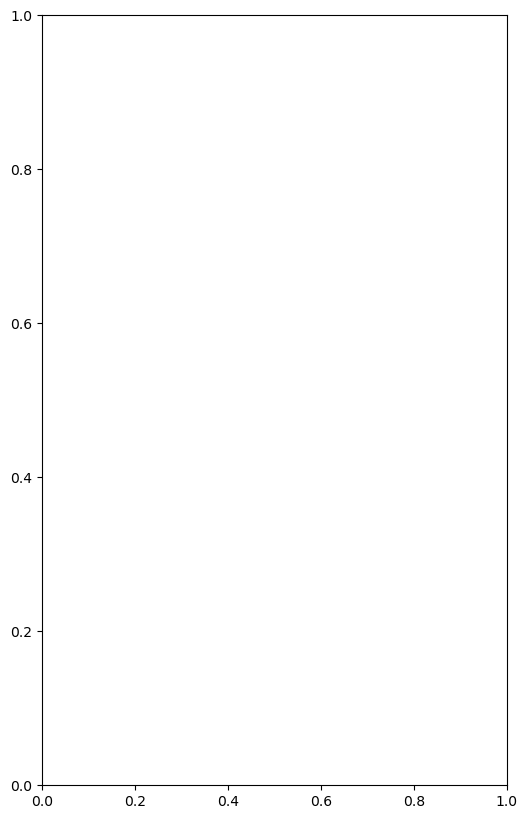

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns 
plt.figure(figsize=(6,10))
sns.boxenplot(data=df["Average_Cost_for_two_INR"])
plt.title("Average_cost_INR")
plt.show()

In [90]:
df[df["Average_Cost_for_two_INR"]>10000].head().T

,814,817,819,842,848
RestaurantID,7600914,6103868,6113857,18255631,6102866
RestaurantName,The Witchery & The Secret Garden,Nobu,sketch Gallery,Pier 70,Hakkasan
City,Edinburgh,London,London,Paynesville,London
Locality,Old Town,Mayfair,"Conduit Street, Mayfair",Paynesville,Mayfair
Longitude,-3.19575,-0.143259,-0.141557,147.722783,-0.144861
Latitude,55.948281,51.508811,51.512669,-37.919415,51.510342
Currency,Pounds(Œ£),Pounds(Œ£),Pounds(Œ£),Dollar($),Pounds(Œ£)
Has_Table_booking,Yes,Yes,No,No,Yes
Has_Online_delivery,No,No,No,No,No
Is_delivering_now,No,No,No,No,No


In [91]:
df=df.drop(["new_price_range","Price_range_category"],axis=1)

In [92]:
df["Price_Range_category"]=df["Price_range"].map({1:"Inexpensive",2:"Mid-Range",3:"Expensive",4:"Luxury"})

In [93]:
df.columns

Index(['RestaurantID', 'RestaurantName', 'City', 'Locality', 'Longitude',
       'Latitude', 'Currency', 'Has_Table_booking', 'Has_Online_delivery',
       'Is_delivering_now', 'Price_range', 'Votes', 'Average_Cost_for_two',
       'Rating', 'Datekey_Opening', 'country_name', 'opening_year',
       'opening_month', 'opening_monthname', 'opening_quarter',
       'exchange_rate', 'Average_Cost_for_two_INR', 'Rating_Text',
       'Rating_color', 'All_Cuisines', 'Price_Range_category'],
      dtype='str')

In [94]:
df.shape

(9551, 26)

In [95]:
# making new order for better reading 
new_order=['RestaurantID', 'RestaurantName','City', 'Locality','country_name','All_Cuisines','Longitude','Latitude',
          'Currency','exchange_rate','Average_Cost_for_two','Average_Cost_for_two_INR',
           'Price_range','Price_Range_category',
          'Rating', 'Rating_Text', 'Rating_color','Votes',
          'Datekey_Opening','opening_year','opening_quarter','opening_month', 'opening_monthname',
          'Has_Table_booking', 'Has_Online_delivery','Is_delivering_now']

In [96]:
final_df=df[new_order]

In [97]:
final_df.shape

(9551, 26)

In [98]:
final_df.head().T

,0,1,2,3,4
RestaurantID,18435314,18378015,18424905,18180072,18415377
RestaurantName,Punjabi's Veg Grill,Tasty Tandoor,Taste of Spice,Kolcata Bengali Dhaba,Sunil Punjabi Dhaba
City,New Delhi,New Delhi,New Delhi,New Delhi,New Delhi
Locality,Geeta Colony,Geeta Colony,Lajpat Nagar 1,Mahipalpur,Mahipalpur
country_name,India,India,India,India,India
All_Cuisines,North Indian,North Indian,North Indian,North Indian,North Indian
Longitude,77.276769,77.275052,77.241312,77.123932,77.129706
Latitude,28.650775,28.658216,28.578311,28.543587,28.541369
Currency,Indian Rupees(Rs.),Indian Rupees(Rs.),Indian Rupees(Rs.),Indian Rupees(Rs.),Indian Rupees(Rs.)
exchange_rate,1.0,1.0,1.0,1.0,1.0


In [99]:
final_df.isnull().sum()

RestaurantID                0
RestaurantName              0
City                        0
Locality                    0
country_name                0
All_Cuisines                0
Longitude                   0
Latitude                    0
Currency                    0
exchange_rate               0
Average_Cost_for_two        0
Average_Cost_for_two_INR    0
Price_range                 0
Price_Range_category        0
Rating                      0
Rating_Text                 0
Rating_color                0
Votes                       0
Datekey_Opening             0
opening_year                0
opening_quarter             0
opening_month               0
opening_monthname           0
Has_Table_booking           0
Has_Online_delivery         0
Is_delivering_now           0
dtype: int64

In [100]:
final_df.head()

,RestaurantID,RestaurantName,City,Locality,country_name,All_Cuisines,Longitude,Latitude,Currency,exchange_rate,...,Rating_color,Votes,Datekey_Opening,opening_year,opening_quarter,opening_month,opening_monthname,Has_Table_booking,Has_Online_delivery,Is_delivering_now
0,18435314,Punjabi's Veg Grill,New Delhi,Geeta Colony,India,North Indian,77.276769,28.650775,Indian Rupees(Rs.),1.0,...,Red,0,2013-09-21,2013,3,9,September,No,No,No
1,18378015,Tasty Tandoor,New Delhi,Geeta Colony,India,North Indian,77.275052,28.658216,Indian Rupees(Rs.),1.0,...,Red,0,2016-09-10,2016,3,9,September,No,No,No
2,18424905,Taste of Spice,New Delhi,Lajpat Nagar 1,India,North Indian,77.241312,28.578311,Indian Rupees(Rs.),1.0,...,Red,0,2018-09-25,2018,3,9,September,No,Yes,No
3,18180072,Kolcata Bengali Dhaba,New Delhi,Mahipalpur,India,North Indian,77.123932,28.543587,Indian Rupees(Rs.),1.0,...,Red,0,2018-09-06,2018,3,9,September,No,No,No
4,18415377,Sunil Punjabi Dhaba,New Delhi,Mahipalpur,India,North Indian,77.129706,28.541369,Indian Rupees(Rs.),1.0,...,Red,0,2013-09-17,2013,3,9,September,No,No,No


In [102]:
final_df.to_excel(r"D:\Imarticus pg Diploma\Capstone- Zomato Restaurants Analysis\EDA_cleaned_zomato_dataset_lat.xlsx",index=False)

In [ ]:
# To import whole data into sql server 
# from sqlalchemy import create_engine

# # 1.To store the credentials into variables (safe and clean)
# user = 'root'
# password = 'Kuldeep@#123' 
# host = 'localhost'
# database = 'Zomato_db'

# # 2. Connection string ko dhyan se format karein
# # Note: Agar password mein @, #, ya $ jaise symbols hain, toh unhe 'quote' karna padta hai
# import urllib.parse
# safe_password = urllib.parse.quote_plus(password)

# engine = create_engine(f'mysql+pymysql://{user}:{safe_password}@{host}/{database}')

# # 3.send the data 
# try:
#     final_df.to_sql('zomato', con=engine, if_exists='replace', index=False)
#     print("Success!Loaded complete data into SQL")
# except Exception as e:
#     print(f"Error is there: {e}")

In [ ]:
final_df["Rating"].value_counts()

In [103]:
final_df.head()

,RestaurantID,RestaurantName,City,Locality,country_name,All_Cuisines,Longitude,Latitude,Currency,exchange_rate,...,Rating_color,Votes,Datekey_Opening,opening_year,opening_quarter,opening_month,opening_monthname,Has_Table_booking,Has_Online_delivery,Is_delivering_now
0,18435314,Punjabi's Veg Grill,New Delhi,Geeta Colony,India,North Indian,77.276769,28.650775,Indian Rupees(Rs.),1.0,...,Red,0,2013-09-21,2013,3,9,September,No,No,No
1,18378015,Tasty Tandoor,New Delhi,Geeta Colony,India,North Indian,77.275052,28.658216,Indian Rupees(Rs.),1.0,...,Red,0,2016-09-10,2016,3,9,September,No,No,No
2,18424905,Taste of Spice,New Delhi,Lajpat Nagar 1,India,North Indian,77.241312,28.578311,Indian Rupees(Rs.),1.0,...,Red,0,2018-09-25,2018,3,9,September,No,Yes,No
3,18180072,Kolcata Bengali Dhaba,New Delhi,Mahipalpur,India,North Indian,77.123932,28.543587,Indian Rupees(Rs.),1.0,...,Red,0,2018-09-06,2018,3,9,September,No,No,No
4,18415377,Sunil Punjabi Dhaba,New Delhi,Mahipalpur,India,North Indian,77.129706,28.541369,Indian Rupees(Rs.),1.0,...,Red,0,2013-09-17,2013,3,9,September,No,No,No


In [104]:
final_df["opening_year"].value_counts()

opening_year
2018    1102
2011    1098
2017    1086
2010    1080
2013    1061
2014    1051
2016    1027
2015    1024
2012    1022
Name: count, dtype: int64

In [109]:
final_df["City"].nunique()

141

In [111]:
final_df["Rating_Text"].value_counts()

Rating_Text
Average      3737
Poor         2334
Good         2100
Very Good    1079
Excellent     301
Name: count, dtype: int64